# README

In this notebook:
- We check whether the directories contain the same number of packages and same content.
- Define the buckets that will serve as groups in our experiments. We are not comparing packages with different sizes, thus size it is a blocking factor.

In [1]:
import os, shutil, re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from pathlib import PosixPath

In [2]:
#algos = [
#    'gzip', 'xz', 'zstd', 'brotli', 'zopfli', 'tar'
#]
# (Folders, Extension)
EXTENSIONS = {
    'npm': '.tgz',
    'xz': '.tar.xz',
    'brotli': '.tar.br',
    'zstd': '.tar.zst',
    'zopfli': '.tgz'
}

In [3]:
def return_dir_files(dirname : str):
    '''
    Returns all the files from a specified @dirpath 
    and collects all the files with the expected extension. 
    '''
    if dirname not in EXTENSIONS:
        raise KeyError(f"no extension configured for {dirname!r}")
    target_extension = EXTENSIONS[dirname]
    
    dirpath = Path(dirname)
    if not dirpath.is_dir():
        raise FileNotFoundError(f"directory {dirpath} not found")
    # collects files with expected extension
    return [
        filepath for filepath in dirpath.iterdir()
        if filepath.is_file() and filepath.name.endswith(target_extension)
    ] 

In [4]:
def true_stem(p: Path) -> str:
    name = p.name
    for ext in list(EXTENSIONS.values()):
        if name.endswith(ext):
            return name[: -len(ext)]
    return p.stem

In [5]:
def get_intersection(array : list[list[Path]]):
    '''returns elements in common in list of list of paths'''
    sets = [set(map(lambda p: true_stem(p), l)) for l in array]
    return list(set.intersection(*sets))

In [6]:
def get_sizes(files : list[Path]): 
    return [
        {'name': f, 'size' : f.stat().st_size} for f in files
    ]

In [7]:
allfiles = {
    key : return_dir_files(key) for key in EXTENSIONS
}

sizes = {
    key : pd.DataFrame(get_sizes(allfiles[key])) for key in allfiles
}

for k in sizes:
    sizes[k]['_key'] = sizes[k]['name'].apply(true_stem)
# list of strings
# intersection = get_intersection(list(allfiles.values()))

# Sampling
The population has packages varying in size min(~360 byte to 45 MB)

In [8]:
# original sample
baseline = pd.DataFrame(sizes['npm'])
baseline['_key'] = baseline['name'].apply(true_stem)
baseline.describe().apply(lambda s: s.apply('{0:.5f}'.format))

,size
count,2500.00000
mean,243881.03680
std,2607170.85336
min,357.00000
25%,2995.00000
50%,5522.00000
75%,14446.25000
max,45191121.00000


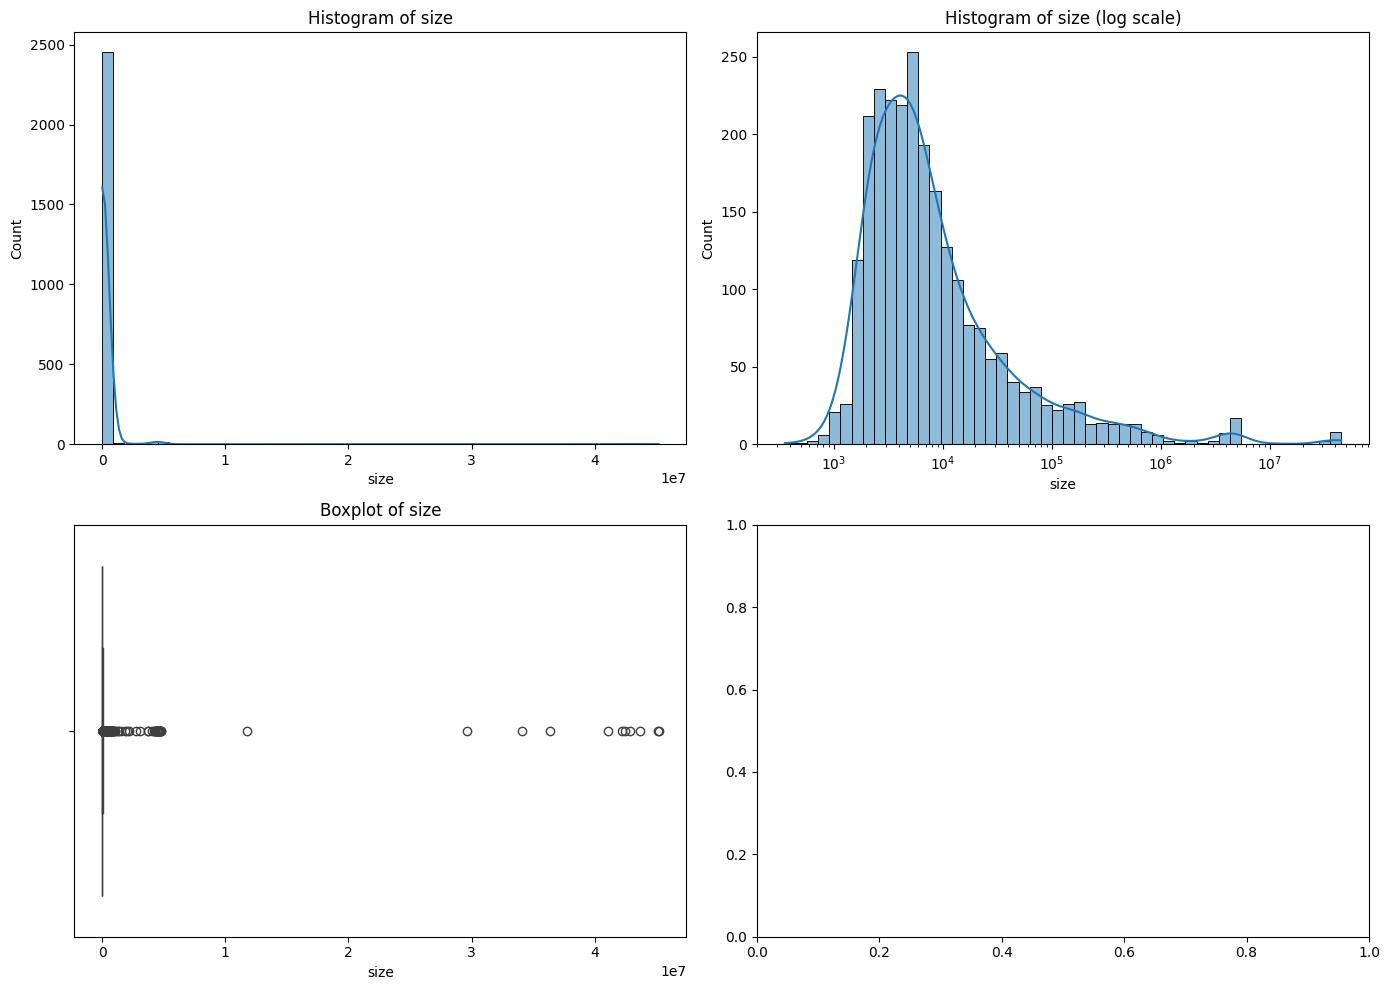

In [9]:
df = baseline
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['size'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram of size')

sns.histplot(df['size'], bins=50, log_scale=True, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Histogram of size (log scale)')

# 3. Boxplot to spot outliers
sns.boxplot(x=df['size'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of size')

plt.tight_layout()
plt.savefig('size_distribution.png', dpi=150)
plt.show()

In [20]:
# Get sample from NPM (TAR) packages
## Identify and collapse "family" duplicates
PLATFORM_SUFFIX_RE = re.compile(
    r'(-|__)(win32|darwin|linux|freebsd|openbsd|netbsd|sunos|aix|android)'
    r'(-(x64|ia32|arm64|arm|mips64el|ppc64|s390x|riscv64|loong64|universal))?'
    r'(-(gnu|musl|msvc))?$'
)

def assign_family(path) -> str:
    """Collapse platform-specific builds of the same package into one family.
    e.g. '@esbuild__linux-x64--linux-x64-0.28.0' -> family '@esbuild'
         'lodash--lodash-4.17.21'                -> family 'lodash' (unchanged)
    """
    pkg_part = path.name.split('--')[0]
    return PLATFORM_SUFFIX_RE.sub('', pkg_part)
 
df = baseline.copy()
df['family'] = df['name'].apply(assign_family)
df['log_size'] = np.log10(df['size'])
 
# Step 1: one representative per family
parts = []
for _, g in df.groupby('family'):
    parts.append(g.sample(1, random_state=42))
dedup = pd.concat(parts)
dedup

# Step 2: equal-width bins in log-size space
edges = np.linspace(
    dedup['log_size'].min(), dedup['log_size'].max() + 1e-9, 20
)
dedup = dedup.copy()
dedup['bin'] = pd.cut(dedup['log_size'], bins=edges, labels=False, include_lowest=True)

parts = []
for _, g in dedup.groupby('bin'):
    parts.append(g.sample(n=min(4, len(g)), random_state=42))
sample = pd.concat(parts)

sample = sample.sort_values('size').reset_index(drop=True)

In [21]:
sample.to_csv(f'./samples/npm.csv', index=False)

In [22]:
# for each population (e.g.,  xz, zopfli)
# get the sampled packages
algos = EXTENSIONS.keys() - ['npm']
for k in algos:
    current_sample = sizes[k].copy()
    current_sample = current_sample[
                        current_sample['_key'].isin(sample['_key'])
                     ]
    current_sample = current_sample.sort_values('_key').reset_index(drop=True) 
    current_sample.to_csv(f'./samples/{k}.csv', index=False)